In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.diagnostic import het_breuschpagan

In [54]:
env = pd.read_csv("../data/raw/env_air_.csv")
pop = pd.read_csv("../data/raw/pop.csv")
merged_eu_27 = pd.read_csv("../data/raw/processed/eu_renewable_emissions.csv")

In [3]:
env.head()

,freq,unit,airpol,src_crf,geo\TIME_PERIOD,1990,1991,1992,1993,1994,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,A,MIO_T,CH4,CRF1,AT,0.05442,0.04970,0.04877,0.04635,0.03954,...,0.03087,0.03084,0.03199,0.02887,0.02811,0.02726,0.02873,0.02657,0.02694,0.02640
1,A,MIO_T,CH4,CRF1,BE,0.05939,0.05471,0.04767,0.04917,0.04371,...,0.03360,0.03342,0.03254,0.03197,0.03242,0.03087,0.03251,0.02870,0.02924,0.02843
2,A,MIO_T,CH4,CRF1,BG,0.09989,0.08456,0.09399,0.09496,0.08775,...,0.06470,0.06125,0.06590,0.06000,0.05644,0.05303,0.05795,0.06133,0.04673,0.03940
3,A,MIO_T,CH4,CRF1,CH,0.01529,0.01563,0.01496,0.01415,0.01324,...,0.00606,0.00601,0.00591,0.00542,0.00527,0.00495,0.00514,0.00455,0.00440,0.00430
4,A,MIO_T,CH4,CRF1,CY,0.00051,0.00052,0.00052,0.00052,0.00054,...,0.00065,0.00067,0.00074,0.00074,0.00077,0.00075,0.00076,0.00079,0.00072,0.00071


In [ ]:
env_long = env.copy()

env_long = env_long.melt(id_vars=["freq", "unit", "airpol", "src_crf", "geo\\TIME_PERIOD"], var_name="year")
env_long = env_long.drop(columns="freq")

env_long.head()

,unit,airpol,src_crf,geo\TIME_PERIOD,year,value
0,MIO_T,CH4,CRF1,AT,1990,0.05442
1,MIO_T,CH4,CRF1,BE,1990,0.05939
2,MIO_T,CH4,CRF1,BG,1990,0.09989
3,MIO_T,CH4,CRF1,CH,1990,0.01529
4,MIO_T,CH4,CRF1,CY,1990,0.00051


In [27]:
env_gases = env_long[(env_long["unit"] == "MIO_T") & (env_long["src_crf"] == "TOTXMEMO")]

for i in ["airpol", "unit"]:
    print(env_gases[i].unique())

env_gases = env_gases[env_gases["year"]>="2004"]

env_gases

['CH4' 'CH4_CO2E' 'CO2' 'GHG' 'HFC_CO2E' 'HFC_PFC_NSP_CO2E' 'N2O'
 'N2O_CO2E' 'NF3_CO2E' 'PFC_CO2E' 'SF6_CO2E']
['MIO_T']


,unit,airpol,src_crf,geo\TIME_PERIOD,year,value
746116,MIO_T,CH4,TOTXMEMO,AT,2004,0.33171
746117,MIO_T,CH4,TOTXMEMO,BE,2004,0.34821
746118,MIO_T,CH4,TOTXMEMO,BG,2004,0.30445
746119,MIO_T,CH4,TOTXMEMO,CH,2004,0.19371
746120,MIO_T,CH4,TOTXMEMO,CY,2004,0.03528
...,...,...,...,...,...,...
1829116,MIO_T,SF6_CO2E,TOTXMEMO,RO,2024,0.04527
1829117,MIO_T,SF6_CO2E,TOTXMEMO,SE,2024,0.04170
1829118,MIO_T,SF6_CO2E,TOTXMEMO,SI,2024,0.01230
1829119,MIO_T,SF6_CO2E,TOTXMEMO,SK,2024,0.00590


In [32]:
teste = env_gases[(env_gases["geo\TIME_PERIOD"]=="PT") & (env_gases["year"]=="2020")]
teste[["airpol","value"]].sort_values(by="value", ascending=False)

,airpol,value
1607085,GHG,55.22422
1601863,CO2,39.39920
1598326,CH4_CO2E,10.23559
1615364,N2O_CO2E,3.67221
1607790,HFC_CO2E,1.90442
1594430,CH4,0.36556
1611804,N2O,0.01386
1617043,SF6_CO2E,0.01279


In [34]:
gases_dominantes = ["CO2", "CH4_CO2E", "N2O_CO2E"]
env_gases_final = env_gases[env_gases["airpol"].isin(gases_dominantes)]

In [35]:
eu27 = ["AT", "BE", "BG", "HR", "CY", "CZ", "DK", "EE", "FI", "FR",
        "DE", "EL", "HU", "IE", "IT", "LV", "LT", "LU", "MT", "NL",
        "PL", "PT", "RO", "SK", "SI", "ES", "SE"]

env_gases_final = env_gases_final[env_gases_final["geo\\TIME_PERIOD"].isin(eu27)]

In [37]:
env_gases_final = env_gases_final.rename(columns={"geo\\TIME_PERIOD": "pais"})

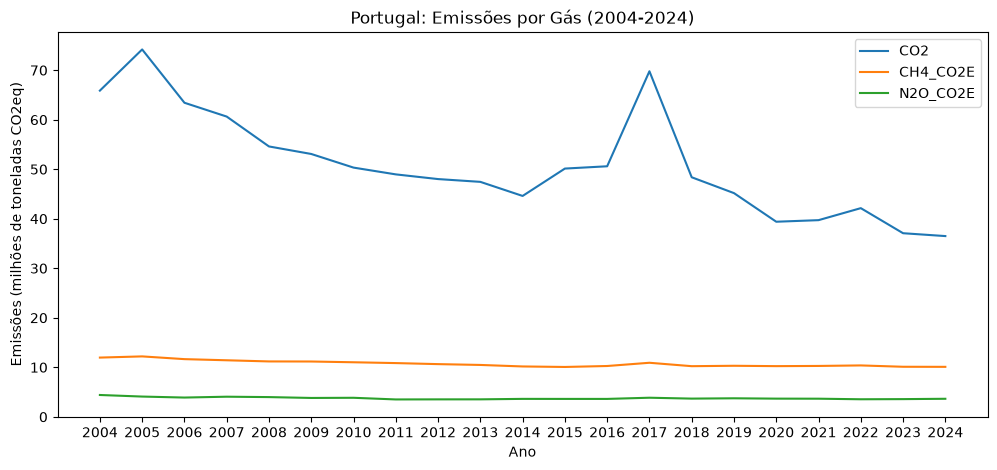

In [41]:
pt_gases = env_gases_final[env_gases_final["pais"] == "PT"]

plt.figure(figsize=(12, 5))

for gas in gases_dominantes:
    sub = pt_gases[pt_gases["airpol"] == gas]
    plt.plot(sub["year"], sub["value"], label=gas)

plt.legend()
plt.xlabel("Ano")
plt.ylabel("Emissões (milhões de toneladas CO2eq)")
plt.title("Portugal: Emissões por Gás (2004-2024)")
plt.show()

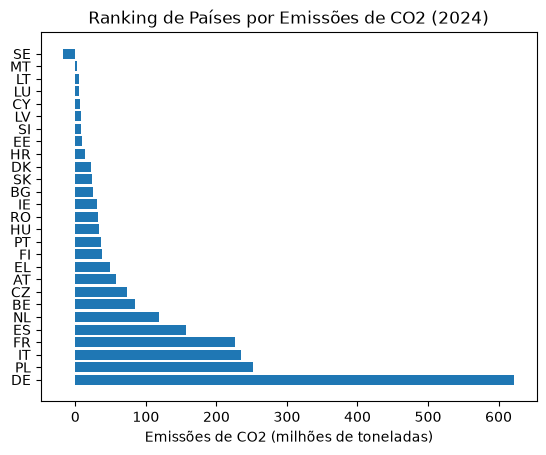

In [63]:
co2_geral = env_gases_final[(env_gases_final["airpol"] == "CO2") & (env_gases_final["year"] == "2024")]
co2_geral = co2_geral.sort_values(by="value", ascending=False)


plt.Figure(figsize=(10,8))
plt.barh(co2_geral["pais"], co2_geral["value"])
plt.xlabel("Emissões de CO2 (milhões de toneladas)")
plt.title("Ranking de Países por Emissões de CO2 (2024)")
plt.show()

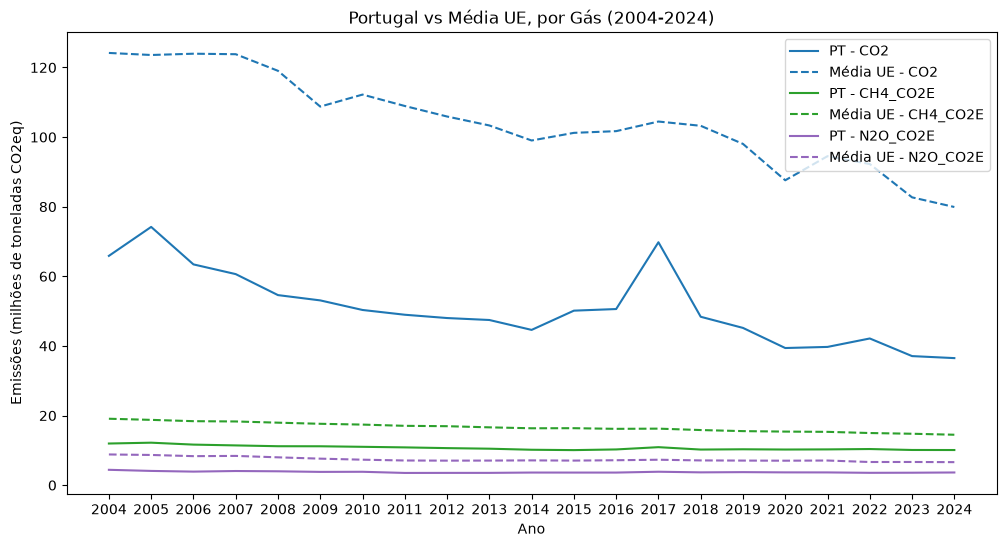

In [66]:
media_eu_gases = env_gases_final.groupby(["year", "airpol"])["value"].mean().reset_index()

cores = {"CO2": "tab:blue", "CH4_CO2E": "tab:green", "N2O_CO2E": "tab:purple"}

plt.figure(figsize=(12, 6))

for gas in gases_dominantes:
    sub_pt = pt_gases[pt_gases["airpol"] == gas]
    sub_eu = media_eu_gases[media_eu_gases["airpol"] == gas]

    plt.plot(sub_pt["year"], sub_pt["value"], color = cores[gas], label=f"PT - {gas}")
    plt.plot(sub_eu["year"], sub_eu["value"], color = cores[gas], linestyle="--", label=f"Média UE - {gas}")

plt.legend()
plt.xlabel("Ano")
plt.ylabel("Emissões (milhões de toneladas CO2eq)")
plt.title("Portugal vs Média UE, por Gás (2004-2024)")
plt.show()

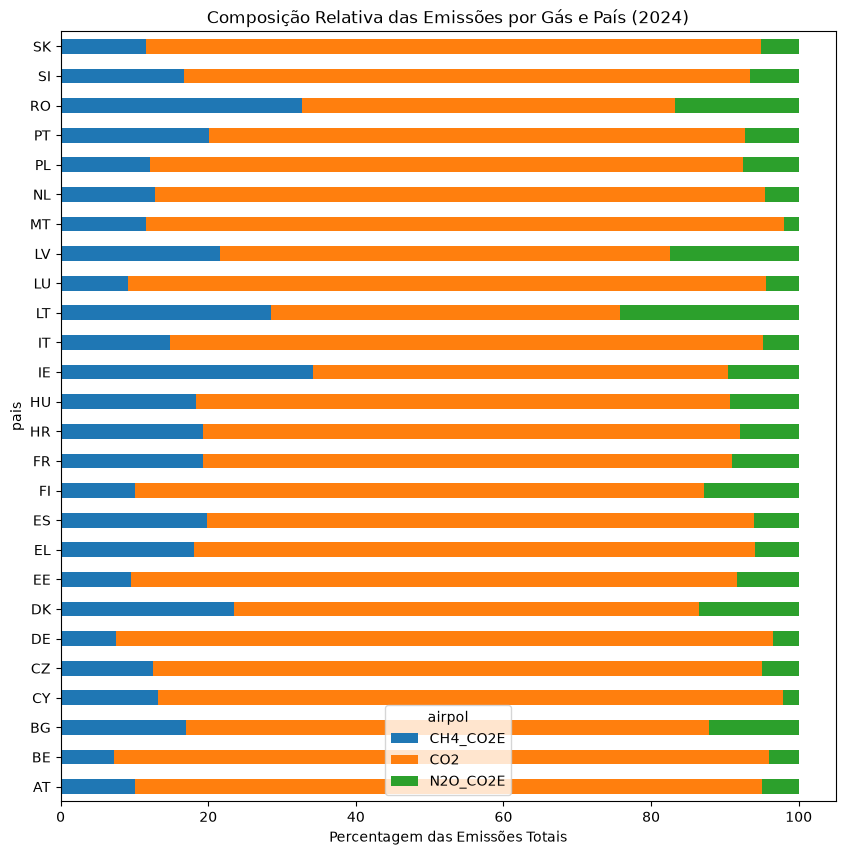

In [71]:
gas_2024 = env_gases_final[env_gases_final["year"] == "2024"]
gas_pivot = gas_2024.pivot(index="pais", columns="airpol", values="value")
gas_percent = gas_pivot.div(gas_pivot.sum(axis=1), axis=0) * 100
gas_percent_sem_se = gas_percent.drop("SE")

gas_percent_sem_se.plot(kind="barh", stacked=True, figsize=(10, 10))
plt.xlabel("Percentagem das Emissões Totais")
plt.title("Composição Relativa das Emissões por Gás e País (2024)")
plt.show()

Extensão: Normalização por população

In [43]:
pop.head()

,freq,unit,age,sex,geo\TIME_PERIOD,1960,1961,1962,1963,1964,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,A,NR,TOTAL,F,AD,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,37388.0,NaN,NaN,NaN,NaN,NaN,NaN
1,A,NR,TOTAL,F,AL,NaN,NaN,NaN,NaN,NaN,...,1417141.0,1423050.0,1431715.0,1432833.0,1425342.0,1419759.0,1406532.0,1394864.0,NaN,1194597.0
2,A,NR,TOTAL,F,AM,NaN,NaN,NaN,NaN,NaN,...,1569535.0,1567380.0,1564533.0,1563538.0,1562689.0,1565144.0,NaN,1571757.0,1577675.0,NaN
3,A,NR,TOTAL,F,AT,3757167.0,3773097.0,3794130.0,3814191.0,3836415.0,...,4427918.0,4460424.0,4483749.0,4501742.0,4522292.0,4535712.0,4553444.0,4619957.0,4643918.0,4664333.0
4,A,NR,TOTAL,F,AZ,NaN,NaN,NaN,NaN,NaN,...,4870002.0,4918771.0,4960058.0,4999053.0,5039100.0,5065288.0,5081846.0,5087516.0,5113564.0,5135511.0


In [47]:
pop_long = pop.melt(["freq", "unit", "age", "sex", 	"geo\TIME_PERIOD"], var_name="year")

In [ ]:
for unique in ["unit", "age", "sex"]:
    print(pop_long[unique].unique())


['NR']
['TOTAL' 'UNK' 'Y1' 'Y10' 'Y11' 'Y12' 'Y13' 'Y14' 'Y15' 'Y16' 'Y17' 'Y18'
 'Y19' 'Y2' 'Y20' 'Y21' 'Y22' 'Y23' 'Y24' 'Y25' 'Y26' 'Y27' 'Y28' 'Y29'
 'Y3' 'Y30' 'Y31' 'Y32' 'Y33' 'Y34' 'Y35' 'Y36' 'Y37' 'Y38' 'Y39' 'Y4'
 'Y40' 'Y41' 'Y42' 'Y43' 'Y44' 'Y45' 'Y46' 'Y47' 'Y48' 'Y49' 'Y5' 'Y50'
 'Y51' 'Y52' 'Y53' 'Y54' 'Y55' 'Y56' 'Y57' 'Y58' 'Y59' 'Y6' 'Y60' 'Y61'
 'Y62' 'Y63' 'Y64' 'Y65' 'Y66' 'Y67' 'Y68' 'Y69' 'Y7' 'Y70' 'Y71' 'Y72'
 'Y73' 'Y74' 'Y75' 'Y76' 'Y77' 'Y78' 'Y79' 'Y8' 'Y80' 'Y81' 'Y82' 'Y83'
 'Y84' 'Y85' 'Y86' 'Y87' 'Y88' 'Y89' 'Y9' 'Y90' 'Y91' 'Y92' 'Y93' 'Y94'
 'Y95' 'Y96' 'Y97' 'Y98' 'Y99' 'Y_LT1' 'Y_OPEN']
['F' 'M' 'T']


In [52]:
pop_total = pop_long[(pop_long["age"] == "TOTAL") & (pop_long["sex"] == "T")]

pop_total = pop_total[(pop_long["year"] >= "2004") & (pop_long["year"] <= "2024")]

pop_total = pop_total.rename(columns={"geo\\TIME_PERIOD": "pais"})
pop_total = pop_total.rename(columns={"value": "populacao"})

pop_total = pop_total.drop(columns="freq")
pop_total = pop_total[pop_total["pais"].isin(eu27)]

pop_total.head()

C:\Users\Artur Albuquerque\AppData\Local\Temp\ipykernel_6284\3296796587.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pop_total = pop_total[(pop_long["year"] >= "2004") & (pop_long["year"] <= "2024")]


,unit,age,sex,pais,year,populacao
780901,NR,TOTAL,T,AT,2004,8142573.0
780904,NR,TOTAL,T,BE,2004,10396421.0
780905,NR,TOTAL,T,BG,2004,7745147.0
780908,NR,TOTAL,T,CY,2004,722893.0
780909,NR,TOTAL,T,CZ,2004,10195347.0


In [56]:
print(merged_eu_27["year"].dtype)
print(pop_total["year"].dtype)

int64
object


In [76]:
pop_total["year"] = pop_total["year"].astype(int)
emissoes_percapita = pd.merge(merged_eu_27, pop_total[["pais","year", "populacao"]], on=["pais", "year"], how="inner")

emissoes_percapita = emissoes_percapita[emissoes_percapita["energia_ren"] == "REN"]
emissoes_percapita["emissoes_per_capita"] = emissoes_percapita["mio_t_co2eq"] * 1000000 / emissoes_percapita["populacao"]

emissoes_percapita.head()

,energia_ren,pais,year,percentagem,mio_t_co2eq,meta_eu,populacao,emissoes_per_capita
0,REN,AT,2004,22.553,76.16585,19.947,8142573.0,9.354027
1,REN,BE,2004,1.916,146.05407,40.584,10396421.0,14.048495
2,REN,BG,2004,9.231,48.69074,33.269,7745147.0,6.286613
3,REN,CY,2004,3.071,9.02067,39.429,722893.0,12.478569
4,REN,CZ,2004,6.773,139.10302,35.727,10195347.0,13.643775


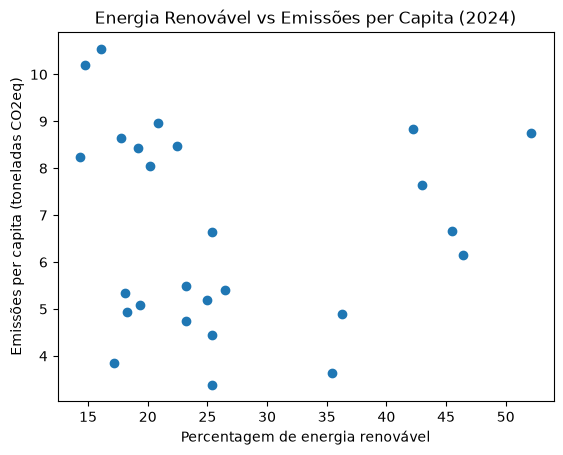

In [78]:
scatter_percen = emissoes_percapita[emissoes_percapita["year"] == 2024]
scatter_percen = scatter_percen[scatter_percen["pais"] != "SE"] 

plt.scatter(scatter_percen["percentagem"], scatter_percen["emissoes_per_capita"])
plt.xlabel("Percentagem de energia renovável")
plt.ylabel("Emissões per capita (toneladas CO2eq)")
plt.title("Energia Renovável vs Emissões per Capita (2024)")
plt.show()

Extensão 2: Previsão da Meta de Renováveis em Portugal

In [121]:
pt_previsao = merged_eu_27[(merged_eu_27["pais"] == "PT") & (merged_eu_27["energia_ren"] == "REN")]

print(pt_previsao.columns)
print(pt_previsao.head())
print(pt_previsao.shape)

Index(['energia_ren', 'pais', 'year', 'percentagem', 'mio_t_co2eq', 'meta_eu'], dtype='object')
    energia_ren pais  year  percentagem  mio_t_co2eq  meta_eu
22          REN   PT  2004       19.205     82.97295   23.295
130         REN   PT  2005       19.523     91.31144   22.977
238         REN   PT  2006       20.792     79.90483   21.708
346         REN   PT  2007       21.907     77.20876   20.593
454         REN   PT  2008       22.929     71.03892   19.571
(21, 6)


In [122]:
X = pt_previsao["year"]
y = pt_previsao["percentagem"]

X = sm.add_constant(X)

modelo_ols = sm.OLS(y, X).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            percentagem   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     600.6
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           7.69e-16
Time:                        15:32:20   Log-Likelihood:                -28.260
No. Observations:                  21   AIC:                             60.52
Df Residuals:                      19   BIC:                             62.61
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1710.0971     70.916    -24.114      0.0

In [124]:
bg = acorr_breusch_godfrey(modelo_ols, nlags=1)
print("LM statistic:", bg[0])
print("LM p-value:", bg[1])
print("F statistic:", bg[2])
print("F p-value:", bg[3])

LM statistic: 3.0376729588155964
LM p-value: 0.08135245991634708
F statistic: 3.0440439667596286
F p-value: 0.09808361930001515


In [126]:
bp = het_breuschpagan(modelo_ols.resid, modelo_ols.model.exog)
print("LM statistic:", bp[0])
print("LM p-value:", bp[1])
print("F statistic:", bp[2])
print("F p-value:", bp[3])

LM statistic: 0.2980294519599114
LM p-value: 0.585120422655525
F statistic: 0.27352756463922295
F p-value: 0.6070211670812007


In [132]:
X = sm.add_constant(pt_previsao["year"])
y = pt_previsao["percentagem"]

modelo_ols = sm.OLS(y, X).fit()

previsao_futura = modelo_ols.get_prediction(sm.add_constant(pd.DataFrame({"year": anos_futuros})))
intervalo = previsao_futura.conf_int(alpha=0.05)

constante = modelo_ols.params["const"]
inclinacao = modelo_ols.params["year"]

ano_meta_europeia = (42.5 - constante) / inclinacao
ano_meta_nacional = (51 - constante) / inclinacao

print(intervalo)
print(ano_meta_europeia, ano_meta_nacional)

[[18.32934908 20.05247776]
 [19.25439664 20.85326656]
 [20.17731606 21.65618351]
 [21.09754551 22.46179042]
 [22.01434839 23.2708239 ]
 [22.9267668  24.08424186]
 [23.83358196 24.90326306]
 [24.73331005 25.72937134]
 [25.62428285 26.5642349 ]
 [26.50486829 27.40948582]
 [27.37383096 28.26635952]
 [28.23070465 29.13532219]
 [29.07595558 30.01590762]
 [29.91081914 30.90688043]
 [30.73692741 31.80660852]
 [31.55594861 32.71342368]
 [32.36936658 33.62584208]
 [33.17840006 34.54264497]
 [33.98400696 35.46287442]
 [34.78692391 36.38579384]
 [35.58771272 37.31084139]
 [36.38680193 38.23758855]
 [37.18452002 39.16570682]
 [37.98112073 40.09494248]
 [38.77680177 41.02509779]
 [39.57171876 41.95601717]
 [40.36599531 42.88757698]
 [41.15973059 43.81967807]
 [41.95300485 44.75224018]
 [42.74588363 45.68519776]
 [43.53842089 46.61849686]
 [44.3306614  47.55209271]
 [45.12264257 48.4859479 ]
 [45.9143959  49.42003094]
 [46.70594804 50.35431517]
 [47.49732171 51.28877785]
 [48.2885364  52.22339953]
 

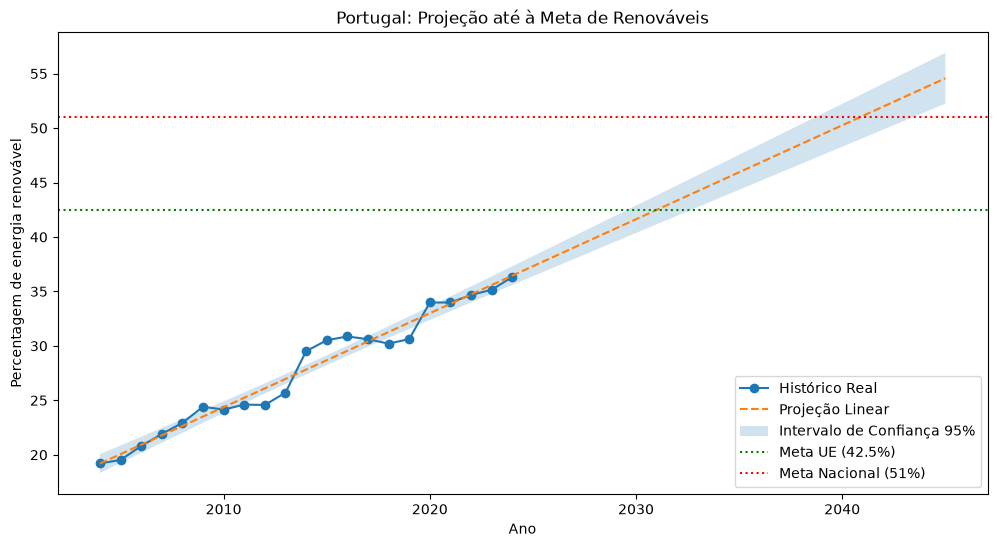

In [133]:
anos_futuros = list(range(2004, 2046))
valores_previstos = [inclinacao * ano + constante for ano in anos_futuros]
limite_inferior = intervalo[:, 0]
limite_superior = intervalo[:, 1]

plt.figure(figsize=(12, 6))
plt.plot(pt_previsao["year"], pt_previsao["percentagem"], marker="o", label="Histórico Real")
plt.plot(anos_futuros, valores_previstos, linestyle="--", label="Projeção Linear")
plt.fill_between(anos_futuros, limite_inferior, limite_superior, alpha=0.2, label="Intervalo de Confiança 95%")
plt.axhline(y=42.5, color="green", linestyle=":", label="Meta UE (42.5%)")
plt.axhline(y=51, color="red", linestyle=":", label="Meta Nacional (51%)")
plt.legend()
plt.xlabel("Ano")
plt.ylabel("Percentagem de energia renovável")
plt.title("Portugal: Projeção até à Meta de Renováveis")
plt.show()